# Stationarity test for each Dataset

In [44]:
import pandas as pd
import numpy as np
import json
import re
import traceback

from multiprocessing import Pool
from functools import partial

from glob import glob

from tqdm import tqdm

from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt

from pathlib import Path

def stats(results_df):
    counts = results_df['stationary'].value_counts()
    total = len(results_df)

    # Print counts and percentages
    print("Stationary series:", counts.get(True, 0))
    print("Non-stationary series:", counts.get(False, 0))
    print()
    print("Stationary (%):", counts.get(True, 0) / total * 100)
    print("Non-stationary (%):", counts.get(False, 0) / total * 100)

    counts = results_df['stationary'].value_counts().reindex([True, False]).fillna(0)

    plt.figure(figsize=(5, 4))
    counts.plot(kind='bar', color=['green', 'red'])
    plt.title('Stationarity of Time Series')
    plt.ylabel('Count')
    plt.xticks([0, 1], ['Stationary', 'Non-Stationary'], rotation=0)
    plt.tight_layout()
    plt.show()

def compute_stationarity(ts_df, dataset):
    results = []

    grouped = ts_df.groupby("id")
    for group_id, group_df in tqdm(grouped, total=len(grouped), desc=f"Computing stationarity for dataset {dataset}"):
        # print(group_id)
        ts_values = group_df.sort_values(by="dt#").y.values

        if len(ts_values) < 10000:
            stat_result = adfuller(ts_values)
        else:
            print("ts_len > 10.000 points. Setting maxlag = 5")
            stat_result = adfuller(ts_values, maxlag=5, autolag=None)

        results.append({
            "dataset": dataset,
            "id": group_id,
            "ADF_stat": stat_result[0],
            "ADF_pval": stat_result[1],
            "stationary": bool(stat_result[1] < 0.05)
        })

    return pd.DataFrame(results)

## Steady State Detection

In [3]:
# utils
TS_PATH = ""

def load_timeseries(benchmark):
    return load(TS_PATH, benchmark)


def load(dirpath, benchmark):
    path = '{}/{}.json'.format(dirpath, benchmark)
    with open(path) as f:
        return json.load(f)

def process_timeseries(benchmark):
    # print('Processing ' + benchmark + ' ...')

    timeseries = load_timeseries(benchmark)

    dfs = []
    for f, ts_ in enumerate(timeseries):
        df = pd.DataFrame(ts_, columns = ["y"])
        df["benchmark_id"] = benchmark
        df["no_fork"] = f
        df["dt#"] = range(len(ts_))
        dfs.append(df)

    # print('Ending processing of ' + benchmark, "len of dfs = ", len(dfs))
    
    if dfs:
        return pd.concat(dfs)
    return pd.DataFrame()

def get_benchmark_list():
    benchmarks = []
    for path in glob(TS_PATH + '/*.json'):
        benchmark = re.sub(r'\.json$', '', path.split('/')[-1])
        benchmarks.append(benchmark)

    return np.unique(benchmarks).tolist()

def load_dataset(sort=False, stratify=False):
    with Pool() as pool:
        fn = partial(process_timeseries)
        dfs = pool.map(fn, get_benchmark_list())
        df =  pd.concat(dfs, ignore_index=True)

        if sort:
            df.sort_values(["benchmark_id", "no_fork"], inplace=True)

        return df

In [4]:
#### JMH DATASET ####

# overwrite TS_PATH
TS_PATH = "./steady-state/jmh/data/timeseries"

# load dataset
ts = load_dataset(sort = True)

ts["id"] = ts["benchmark_id"] + "---" + ts["no_fork"].astype(str)
ts = ts[["id", "dt#", "y"]]


In [5]:
ts

,id,dt#,y
0,HdrHistogram__HdrHistogram#bench.HdrHistogramE...,0,4.069923e-05
1,HdrHistogram__HdrHistogram#bench.HdrHistogramE...,1,3.004359e-05
2,HdrHistogram__HdrHistogram#bench.HdrHistogramE...,2,2.937754e-05
3,HdrHistogram__HdrHistogram#bench.HdrHistogramE...,3,2.938288e-05
4,HdrHistogram__HdrHistogram#bench.HdrHistogramE...,4,2.939011e-05
...,...,...,...
17579995,zalando__logbook#org.zalando.logbook.json.Json...,2995,6.802827e-08
17579996,zalando__logbook#org.zalando.logbook.json.Json...,2996,6.755479e-08
17579997,zalando__logbook#org.zalando.logbook.json.Json...,2997,6.753760e-08
17579998,zalando__logbook#org.zalando.logbook.json.Json...,2998,6.739234e-08


In [ ]:

results = []

grouped = ts.groupby("id")
for group_id, group_df in tqdm(grouped, total=len(grouped), desc="Computing stationarity for dataset"):
    # print(group_id)
    ts_values = group_df.sort_values(by="dt#").y.values

    if len(ts_values) > 100000:
        stat_result = adfuller(ts_values)
    else:
        print("ts_len > 100.000 points. Setting maxlag = 5")
        adfuller(ts, maxlag=5, autolag=None)

    results.append({
        "dataset": "JMH",
        "id": group_id,
        "ADF_stat": stat_result[0],
        "ADF_pval": stat_result[1],
        "stationary": bool(stat_result[1] < 0.05)
    })

pd.DataFrame(results).to_csv("other-data/JMH_stationarity.csv", index=False)

Computing stationarity for dataset: 100%|██████████| 5860/5860 [09:04<00:00, 10.76it/s]


Stationary series: 5639
Non-stationary series: 221

Stationary (%): 96.22866894197952
Non-stationary (%): 3.771331058020478


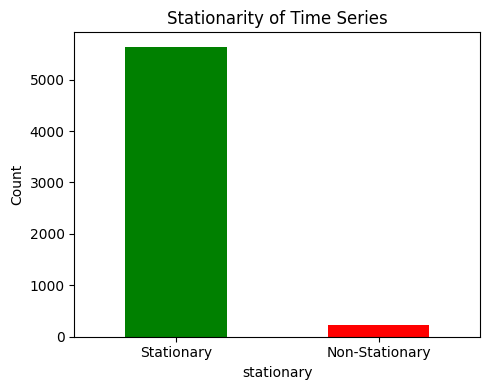

In [11]:
stats(pd.DataFrame(results))

In [12]:
#### VMD DATASET ####

# overwrite TS_PATH
TS_PATH = "./steady-state/VMs/VMs-AIPT/data/timeseries"

# load dataset
ts = load_dataset(sort = True)

ts["id"] = ts["benchmark_id"] + "---" + ts["no_fork"].astype(str)
ts = ts[["id", "dt#", "y"]]


In [13]:
results_df = compute_stationarity(ts_df=ts, dataset="VMD")
results_df.to_csv("other-data/VMD_stationarity.csv", index=False)
results_df

Computing stationarity for dataset VMD: 100%|██████████| 3120/3120 [02:54<00:00, 17.90it/s]


,dataset,id,ADF_stat,ADF_pval,stationary
0,VMD,warmup_results_0_8_linux2_i7_4790___C-default-...,-2.727042,6.947455e-02,False
1,VMD,warmup_results_0_8_linux2_i7_4790___C-default-...,-2.805574,5.748198e-02,False
2,VMD,warmup_results_0_8_linux2_i7_4790___C-default-...,-2.609461,9.105750e-02,False
3,VMD,warmup_results_0_8_linux2_i7_4790___C-default-...,-2.598846,9.323598e-02,False
4,VMD,warmup_results_0_8_linux2_i7_4790___C-default-...,-2.847345,5.182260e-02,False
...,...,...,...,...,...
3115,VMD,warmup_results_0_8_openbsd1_i7_4790___V8-defau...,-17.572198,4.046233e-30,True
3116,VMD,warmup_results_0_8_openbsd1_i7_4790___V8-defau...,-7.498028,4.327326e-11,True
3117,VMD,warmup_results_0_8_openbsd1_i7_4790___V8-defau...,-17.624960,3.822654e-30,True
3118,VMD,warmup_results_0_8_openbsd1_i7_4790___V8-defau...,-17.540354,4.192341e-30,True


Stationary series: 2565
Non-stationary series: 555

Stationary (%): 82.21153846153845
Non-stationary (%): 17.78846153846154


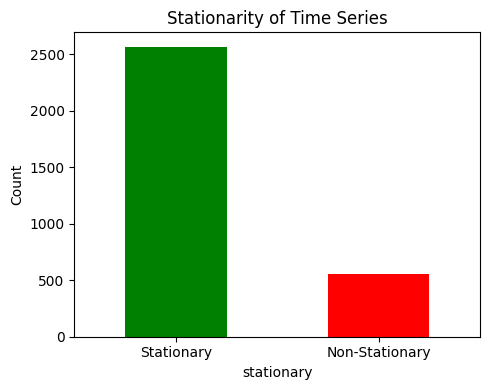

In [14]:
stats(results_df)

## Anomaly Detection

In [37]:
AD_PATH = ""

def load_ad_dataset(dataset):
    ds_path = Path(f"{AD_PATH}/{dataset.upper()}")
    dfs = []
    for ts_path in ds_path.glob("*"):
        # print(f"[{dataset.upper()} processing...] loading time series from {ts_path}")
        # read training set
        training_series = np.load(ts_path / "train.npy")
        training_labels = np.load(ts_path / "train_label.npy")
        dfs.append(
            pd.DataFrame({
                'ts': ts_path.name,
                'dt#': np.arange(len(training_series)), 
                'y': training_series,
                'label': training_labels,
                'split': 'train'
            })
        )

        testing_series = np.load(ts_path / "test.npy")
        testing_labels = np.load(ts_path / "test_label.npy")
        dfs.append(
            pd.DataFrame({
                'ts': ts_path.name,
                'dt#': np.arange(len(testing_series)), 
                'y': testing_series,
                'label': testing_labels,
                'split': 'test'
            })
        )
    assert dfs, f"No time series found in {ds_path}"
    return pd.concat(dfs)

Computing stationarity for dataset AIOPS:   3%|▎         | 1/29 [00:00<00:15,  1.82it/s]

ts_len 299053
ts_len > 10.000 points. Setting maxlag = 5
ts_len 17568
ts_len > 10.000 points. Setting maxlag = 5
ts_len 299053
ts_len > 10.000 points. Setting maxlag = 5


Computing stationarity for dataset AIOPS:  17%|█▋        | 5/29 [00:00<00:03,  6.32it/s]

ts_len 17568
ts_len > 10.000 points. Setting maxlag = 5
ts_len 299053
ts_len > 10.000 points. Setting maxlag = 5


Computing stationarity for dataset AIOPS:  21%|██        | 6/29 [00:01<00:03,  6.51it/s]

...

ts_len 299053
ts_len > 10.000 points. Setting maxlag = 5
ts_len 17568
ts_len > 10.000 points. Setting maxlag = 5
ts_len 299053
ts_len > 10.000 points. Setting maxlag = 5


Computing stationarity for dataset AIOPS:  90%|████████▉ | 26/29 [00:03<00:00,  8.32it/s]

ts_len 216000
ts_len > 10.000 points. Setting maxlag = 5
ts_len 17568
ts_len > 10.000 points. Setting maxlag = 5
ts_len 263590
ts_len > 10.000 points. Setting maxlag = 5


Computing stationarity for dataset AIOPS: 100%|██████████| 29/29 [00:04<00:00,  6.87it/s]


ts_len 263590
ts_len > 10.000 points. Setting maxlag = 5
Stationary series: 29
Non-stationary series: 0

Stationary (%): 100.0
Non-stationary (%): 0.0


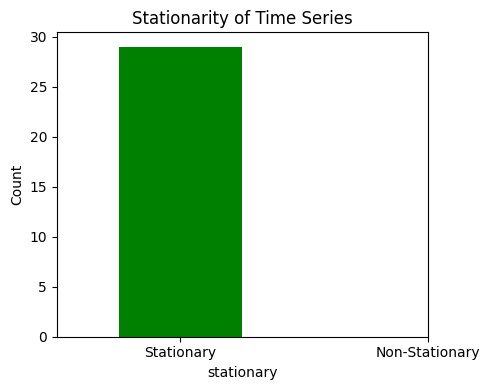

In [38]:
AD_PATH = "./auto-ml/data"
ts = load_ad_dataset("AIOPS")
ts.rename(columns={"ts": "id"}, inplace=True)
results_df = compute_stationarity(ts_df=ts, dataset="AIOPS")
results_df.to_csv("other-data/AIOPS_stationarity.csv", index=False)
stats(results_df)

Computing stationarity for dataset WSD:   3%|▎         | 6/210 [00:00<00:16, 12.54it/s]

ts_len > 10.000 points. Setting maxlag = 5
ts_len > 10.000 points. Setting maxlag = 5
ts_len > 10.000 points. Setting maxlag = 5
ts_len > 10.000 points. Setting maxlag = 5
ts_len > 10.000 points. Setting maxlag = 5
ts_len > 10.000 points. Setting maxlag = 5
ts_len > 10.000 points. Setting maxlag = 5
ts_len > 10.000 points. Setting maxlag = 5
ts_len > 10.000 points. Setting maxlag = 5


Computing stationarity for dataset WSD:   8%|▊         | 16/210 [00:00<00:07, 26.68it/s]

ts_len > 10.000 points. Setting maxlag = 5
ts_len > 10.000 points. Setting maxlag = 5
ts_len > 10.000 points. Setting maxlag = 5
ts_len > 10.000 points. Setting maxlag = 5
ts_len > 10.000 points. Setting maxlag = 5
ts_len > 10.000 points. Setting maxlag = 5
ts_len > 10.000 points. Setting maxlag = 5
ts_len > 10.000 points. Setting maxlag = 5
ts_len > 10.000 points. Setting maxlag = 5


Computing stationarity for dataset WSD:  12%|█▏        | 26/210 [00:01<00:05, 34.47it/s]

...

ts_len > 10.000 points. Setting maxlag = 5
ts_len > 10.000 points. Setting maxlag = 5
ts_len > 10.000 points. Setting maxlag = 5
ts_len > 10.000 points. Setting maxlag = 5
ts_len > 10.000 points. Setting maxlag = 5
ts_len > 10.000 points. Setting maxlag = 5
ts_len > 10.000 points. Setting maxlag = 5
ts_len > 10.000 points. Setting maxlag = 5
ts_len > 10.000 points. Setting maxlag = 5


Computing stationarity for dataset WSD:  98%|█████████▊| 206/210 [00:05<00:00, 42.36it/s]

ts_len > 10.000 points. Setting maxlag = 5
ts_len > 10.000 points. Setting maxlag = 5
ts_len > 10.000 points. Setting maxlag = 5
ts_len > 10.000 points. Setting maxlag = 5
ts_len > 10.000 points. Setting maxlag = 5
ts_len > 10.000 points. Setting maxlag = 5
ts_len > 10.000 points. Setting maxlag = 5
ts_len > 10.000 points. Setting maxlag = 5
ts_len > 10.000 points. Setting maxlag = 5


Computing stationarity for dataset WSD: 100%|██████████| 210/210 [00:05<00:00, 38.82it/s]


ts_len > 10.000 points. Setting maxlag = 5
ts_len > 10.000 points. Setting maxlag = 5
ts_len > 10.000 points. Setting maxlag = 5
Stationary series: 210
Non-stationary series: 0

Stationary (%): 100.0
Non-stationary (%): 0.0


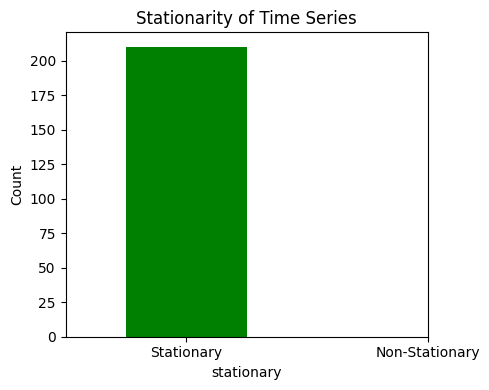

In [40]:
AD_PATH = "./auto-ml/data"
ts = load_ad_dataset("WSD")
ts.rename(columns={"ts": "id"}, inplace=True)
results_df = compute_stationarity(ts_df=ts, dataset="WSD")
results_df.to_csv("other-data/WSD_stationarity.csv", index=False)
stats(results_df)

## Timeseries Forecasting

Computing stationarity for dataset AFD: 100%|██████████| 288/288 [00:16<00:00, 17.61it/s]


Stationary series: 257
Non-stationary series: 31

Stationary (%): 89.23611111111111
Non-stationary (%): 10.76388888888889


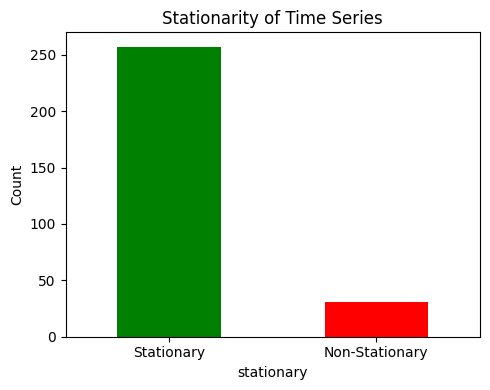

In [45]:
ts = pd.read_csv("./timeseries-forecasting/experiment/data/azure10min.csv")
ts.rename(columns={"ts": "id"}, inplace=True)
results_df = compute_stationarity(ts_df=ts, dataset="AFD")
results_df.to_csv("other-data/AFD_stationarity.csv", index=False)
stats(results_df)